In [1]:
# from xgboost import XGBClassifier
# from xgboost import plot_importance

# model = XGBClassifier(learning_rate=0.01,
#                       n_estimators=10,           # 树的个数-10棵树建立xgboost
#                       max_depth=4,               # 树的深度
#                       min_child_weight = 1,      # 叶子节点最小权重
#                       gamma=0.,                  # 惩罚项中叶子结点个数前的参数
#                       subsample=1,               # 所有样本建立决策树
#                       colsample_btree=1,         # 所有特征建立决策树
#                       scale_pos_weight=1,        # 解决样本个数不平衡的问题
#                       random_state=27,           # 随机数
#                       slient = 0
#                       )
# # 模型训练
# model.fit(X_train,y_train)

# # 模型预测
# y_pred = model.predict(x_test)

In [17]:
# pip install xgboost

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import datasets

In [ ]:
df = pd.read_excel(r"D:\桌面\XGBoost\Machine Learning date.xlsx",sheet_name='normalization')
X = df[['TOTLE', 'SR-PP-PLA-film', 'SR-PP-PLA-injection', 'SR-PP-PLA-other', 'SR-PP-PLA-fiber', 'SR-PP-PHA-injection', 'SR-PP-PHA-woven-goods', 'SR-PP-PBS-film', 'SR-PP-PBS-injection', 'SR-PP-TPS-film',
        'SR-PE-PLA-film', 'SR-PE-PLA-STP', 'SR-PE-PBAT-film', 'SR-PE-PHA-Woven-goods', 'SR-PVC-PHA-injection', 'SR-PVC-PHA-woven-goods', 'SR-PS-PLA-STP',
        'SR-PS-PHA-STP', 'SR-PS-PHA-foam-plastics', 'SR-PS-TPS-STP', 'SR-PET-PLA-bottle', 'SR-PET-PLA-fiber', 'SR-PET-PHA-bottle', ' EPR- Anaerobic digestion ', ' EPR-Compost', ' EPR-Incineration', ' EPR-Landfill', 'UCE-PBS', 'UCE-PBAT',
        'UCE-PHA', 'UCE-PLA', 'UCE-TPS', 'UCE-PET', 'UCE-PP', 'UCE-PS', 'UCE-PVC', 'UCE-PE', 'UCE-Incineration', ' UCE-Landfill', ' UCE-Recycling', ' UCE-Anaerobic digestion', 
        ' UCE-Compost']]
X = X.dropna()
y = X['TOTLE']
X = X[[ 'SR-PP-PLA-film', 'SR-PP-PLA-injection', 'SR-PP-PLA-other', 'SR-PP-PLA-fiber', 'SR-PP-PHA-injection', 'SR-PP-PHA-woven-goods', 'SR-PP-PBS-film', 'SR-PP-PBS-injection', 'SR-PP-TPS-film',
        'SR-PE-PLA-film', 'SR-PE-PLA-STP', 'SR-PE-PBAT-film', 'SR-PE-PHA-Woven-goods', 'SR-PVC-PHA-injection', 'SR-PVC-PHA-woven-goods', 'SR-PS-PLA-STP',
        'SR-PS-PHA-STP', 'SR-PS-PHA-foam-plastics', 'SR-PS-TPS-STP', 'SR-PET-PLA-bottle', 'SR-PET-PLA-fiber', 'SR-PET-PHA-bottle', ' EPR- Anaerobic digestion ', ' EPR-Compost', ' EPR-Incineration', ' EPR-Landfill', 'UCE-PBS', 'UCE-PBAT',
        'UCE-PHA', 'UCE-PLA', 'UCE-TPS', 'UCE-PET', 'UCE-PP', 'UCE-PS', 'UCE-PVC', 'UCE-PE', 'UCE-Incineration', ' UCE-Landfill', ' UCE-Recycling', ' UCE-Anaerobic digestion', 
        ' UCE-Compost']]
X = np.array(X)
y = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 模型训练

In [21]:
# 使用默认参数
model = XGBRegressor()

# model = XGBRegressor(booster='gbtree',  # gblinear
#                      n_estimators=150,  # 迭代次数
#                      learning_rate=0.01,  # 步长
#                      max_depth=10,  # 树的最大深度
#                      min_child_weight=0.5,  # 决定最小叶子节点样本权重和
#                      seed=123,  # 指定随机种子，为了复现结果
#                      )

model.fit(X_train, y_train, verbose=True)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

# 模型评估 

In [22]:
y_pred = model.predict(X_test)
# print(y_pred)

# for m, n in zip(y_pred, y_test):
#     if m / n - 1 > 0.2:
#         print('预测值为{0}, 真实结果为{1}, 预测结果偏差大于20%'.format(m, n))

def metrics_sklearn(y_valid, y_pred_):
    """模型效果评估"""
    r2 = r2_score(y_valid, y_pred_)
    print('R2:{0}'.format(r2))

    MSE = mean_squared_error(y_valid, y_pred_)
    print('MSE:{0}'.format(MSE))

    MAE = mean_absolute_error(y_valid, y_pred)
    print("MAE:", MAE)
"""模型效果评估"""
metrics_sklearn(y_test, y_pred)

R2:0.413744623344231
MSE:0.0027155359871427302
MAE: 0.04323899135939034


# 模型调参

In [14]:
def adj_params():
    """模型调参"""
    params = {
              'booster': ['gbtree', 'gblinear'],
              # 'n_estimators': [20, 50, 100, 150, 200],
              'n_estimators': [75, 125, 200, 250, 300],
              'learning_rate': [0.01, 0.03, 0.05, 0.1],
              'max_depth': [5, 8, 10, 12]
              }

    # model_adj = XGBRegressor()

    other_params = {'subsample': 0.8, 'colsample_bytree': 0.8, 'seed': 123}
    model_adj = XGBRegressor(**other_params)

    # sklearn提供的调参工具，训练集k折交叉验证(消除数据切分产生数据分布不均匀的影响)
    optimized_param = GridSearchCV(estimator=model_adj, param_grid=params, scoring='r2', cv=5, verbose=1)
    # 模型训练
    optimized_param.fit(X_train, y_train)

    # 对应参数的k折交叉验证平均得分
    means = optimized_param.cv_results_['mean_test_score']
    params = optimized_param.cv_results_['params']
    for mean, param in zip(means, params):
        print("mean_score: %f,  params: %r" % (mean, param))
    # 最佳模型参数
    print('参数的最佳取值：{0}'.format(optimized_param.best_params_))
    # 最佳参数模型得分
    print('最佳模型得分:{0}'.format(optimized_param.best_score_))

adj_params()

Fitting 5 folds for each of 160 candidates, totalling 800 fits


c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:26:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "colsample_bytree", "max_depth", "subsample" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:26:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "colsample_bytree", "max_depth", "subsample" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:26:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.c

mean_score: 0.279920,  params: {'booster': 'gbtree', 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 75}
mean_score: 0.354069,  params: {'booster': 'gbtree', 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 125}
mean_score: 0.407157,  params: {'booster': 'gbtree', 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
mean_score: 0.420471,  params: {'booster': 'gbtree', 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 250}
mean_score: 0.424096,  params: {'booster': 'gbtree', 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
mean_score: 0.265326,  params: {'booster': 'gbtree', 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 75}
mean_score: 0.334108,  params: {'booster': 'gbtree', 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 125}
mean_score: 0.381698,  params: {'booster': 'gbtree', 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 200}
mean_score: 0.392770,  params: {'booster': 'gbtree', 'learning_rate': 0.01, 'max_depth': 8, 'n_est

c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:26:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "colsample_bytree", "max_depth", "subsample" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:26:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "colsample_bytree", "max_depth", "subsample" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\si

# 调参结果入模 

In [23]:
model = XGBRegressor(booster='gbtree',  # gblinear
                     n_estimators=300,  # 迭代次数
                     learning_rate=0.3,  # 步长
                     max_depth=3,  # 树的最大深度
                     # min_child_weight=0.5,  # 决定最小叶子节点样本权重和
                     seed=1,  # 指定随机种子，为了复现结果
                     )


model.fit(X_train, y_train, verbose=True)

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.3, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

# 模型保存、加载、调用预测 

In [24]:
"""模型保存"""
model.save_model('xgb_regressor_iris.model')

"""模型加载"""
clf = XGBRegressor()
clf.load_model('xgb_regressor_iris.model')

"""模型参数打印"""
bst = xgb.Booster(model_file='xgb_regressor_iris.model')

# print(bst.attributes())
print('模型参数值-开始'.center(20, '='))
for attr_name, attr_value in bst.attributes().items():
    # scikit_learn 的参数逐一解析
    if attr_name == 'scikit_learn':
        import json

        dict_attr = json.loads(attr_value)
        # 打印 模型 scikit_learn 参数
        for sl_name, sl_value in dict_attr.items():
            if sl_value is not None:
                print(f"{sl_name}:{sl_value}")
    else:
        print(f"{attr_name}:{attr_value}")
print('模型参数值-结束'.center(20, '='))

"""预测验证数据"""
y_pred = clf.predict(X_test)

"""模型效果评估"""
metrics_sklearn(y_test, y_pred)

======模型参数值-开始======
_estimator_type:regressor
======模型参数值-结束======
R2:0.45425090529587464
MSE:0.0025279108143511386
MAE: 0.04164501409480428


c:\Users\monk\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:18:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


# 观察模型拟合效果 

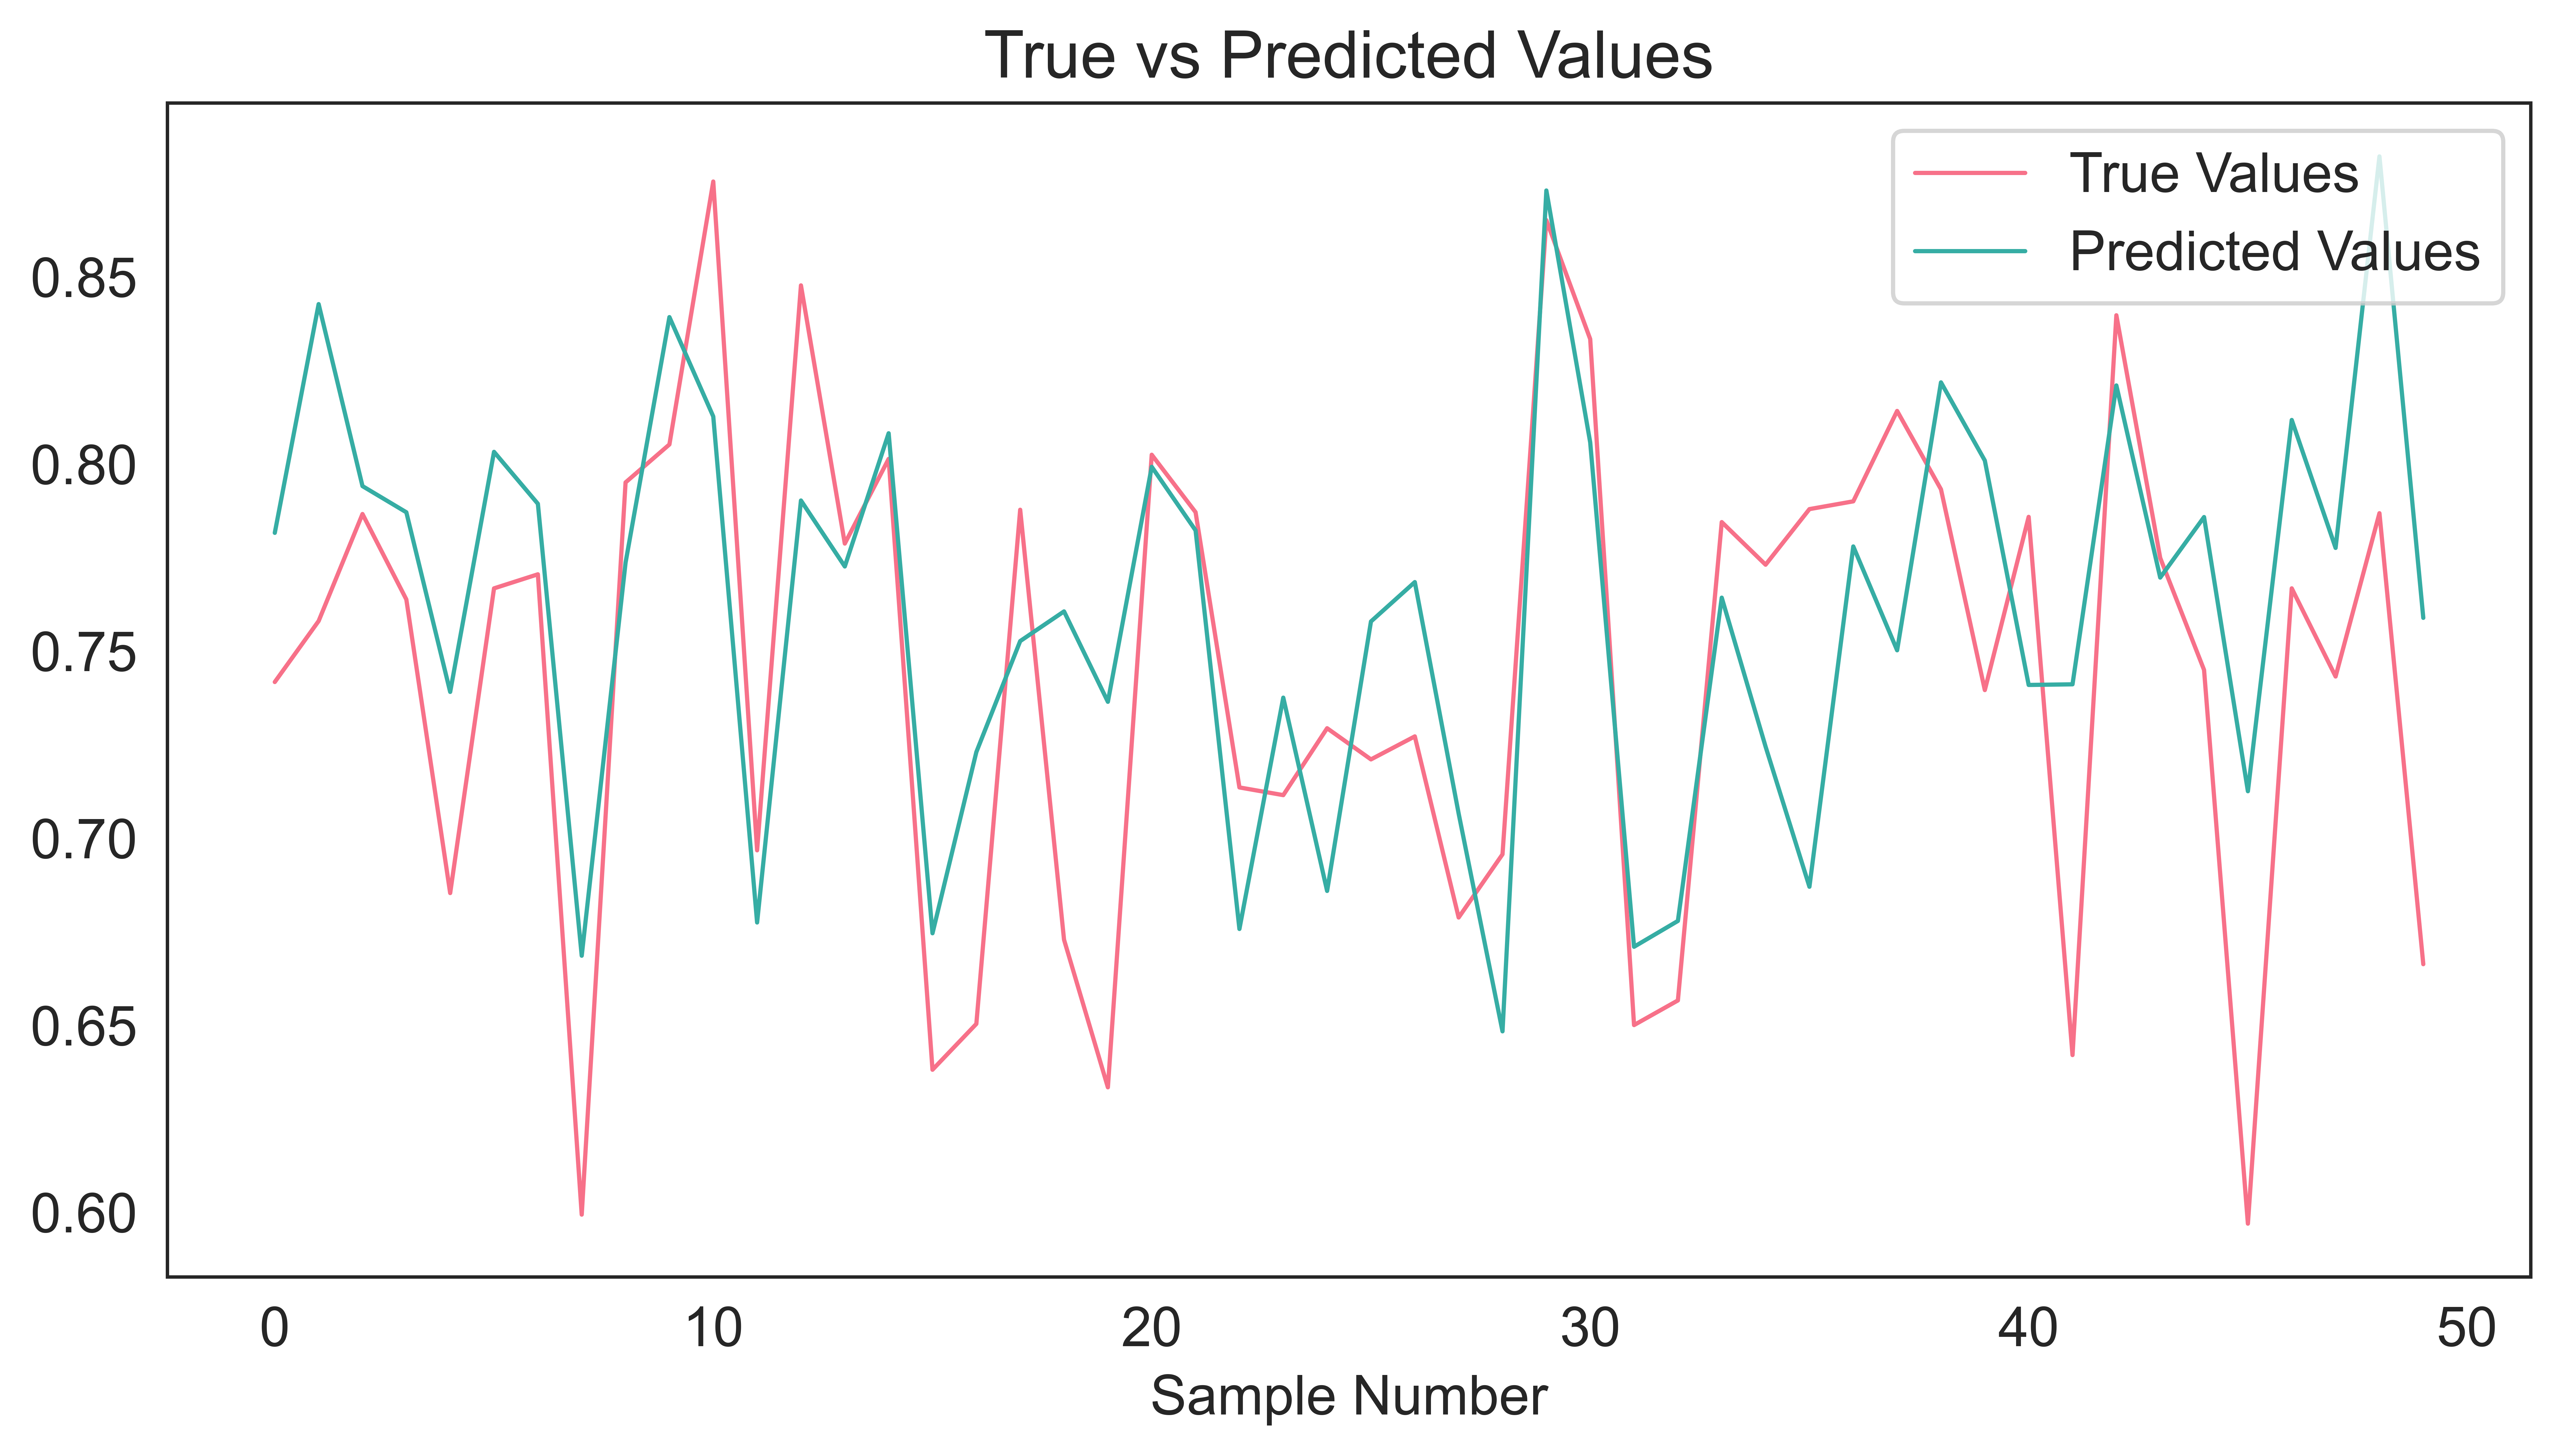

In [25]:
sns.set_style("white") 
palette = sns.color_palette("husl", n_colors=2) 
 
# 设置画布大小和分辨率
plt.figure(figsize=(10, 5), dpi=1080)
 
# 绘制测试集数据的真实值和模型预测值的折线图
x_ax = range(len(y_test[:50]))

plt.plot(x_ax, y_test[:50], label="True Values", color=palette[0], linewidth=1) # 真实值
plt.plot(x_ax, y_pred[:50], label="Predicted Values", color=palette[1], linewidth=1) # 预测值
 
# 添加标题和标签
plt.title("True vs Predicted Values")
plt.xlabel("Sample Number")
# plt.ylabel("CO2 Emissions")
 
# 显示图例
plt.legend()
plt.savefig('True vs Predicted Values.png')
# 显示图形
plt.show()

# shap分析 

In [18]:
# pip install shap

In [26]:
import shap

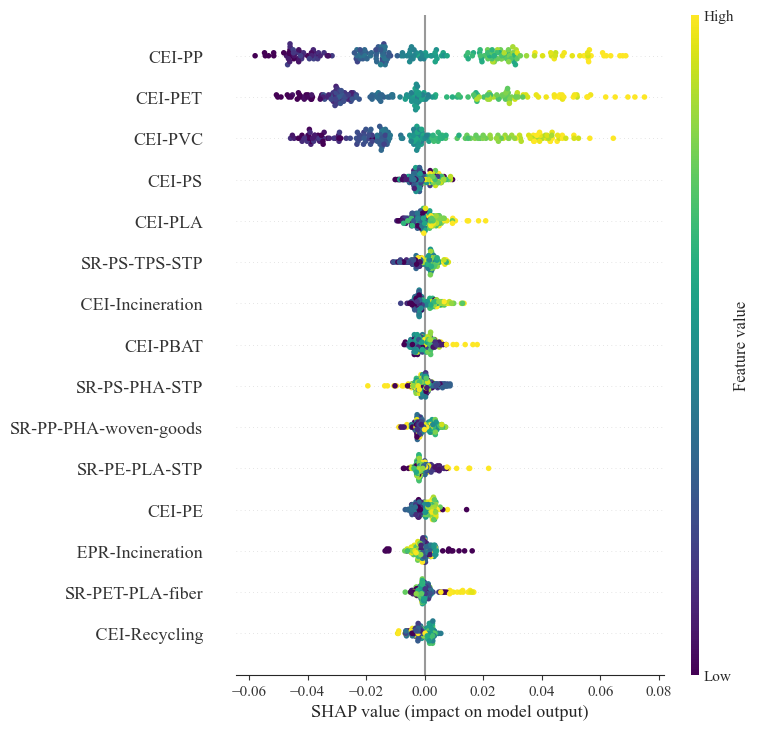

<Figure size 700x600 with 0 Axes>

In [28]:
# SHAP解析
feature_names = [ 'SR-PP-PLA-film', 'SR-PP-PLA-injection', 'SR-PP-PLA-other', 'SR-PP-PLA-fiber', 'SR-PP-PHA-injection', 'SR-PP-PHA-woven-goods', 'SR-PP-PBS-film', 'SR-PP-PBS-injection', 'SR-PP-TPS-film',
                 'SR-PE-PLA-film', 'SR-PE-PLA-STP', 'SR-PE-PBAT-film', 'SR-PE-PHA-Woven-goods', 'SR-PVC-PHA-injection', 'SR-PVC-PHA-woven-goods', 'SR-PS-PLA-STP',
                 'SR-PS-PHA-STP', 'SR-PS-PHA-foam-plastics', 'SR-PS-TPS-STP', 'SR-PET-PLA-bottle', 'SR-PET-PLA-fiber', 'SR-PET-PHA-bottle', ' EPR- Anaerobic digestion ', ' EPR-Compost', ' EPR-Incineration', ' EPR-Landfill', 'CEI-PBS', 'CEI-PBAT',
                 'CEI-PHA', 'CEI-PLA', 'CEI-TPS', 'CEI-PET', 'CEI-PP', 'CEI-PS', 'CEI-PVC', 'CEI-PE', ' CEI-Incineration', ' CEI-Landfill', ' CEI-Recycling', ' CEI-Anaerobic digestion', ' CEI-Compost'
]

X_test = pd.DataFrame(X_test, columns=feature_names)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

#设置字体和大小
plt.rcParams['font.family']='serif'
plt.rcParams['font.serif']= 'Times New Roman'
plt.rcParams['font.size']=13

# 配色有：viridis Spectral coolwarm RdYlGn RdYlBu RdBu RdGy PuOr BrBG PRGn PiYG
shap.summary_plot(shap_values, X_test,cmap='viridis',max_display=15)


# 保存图形为高质量的图片文件
plt.gcf().set_size_inches(7,6)
plt.savefig('picture1.png',dpi=600,bbox_inches='tight')

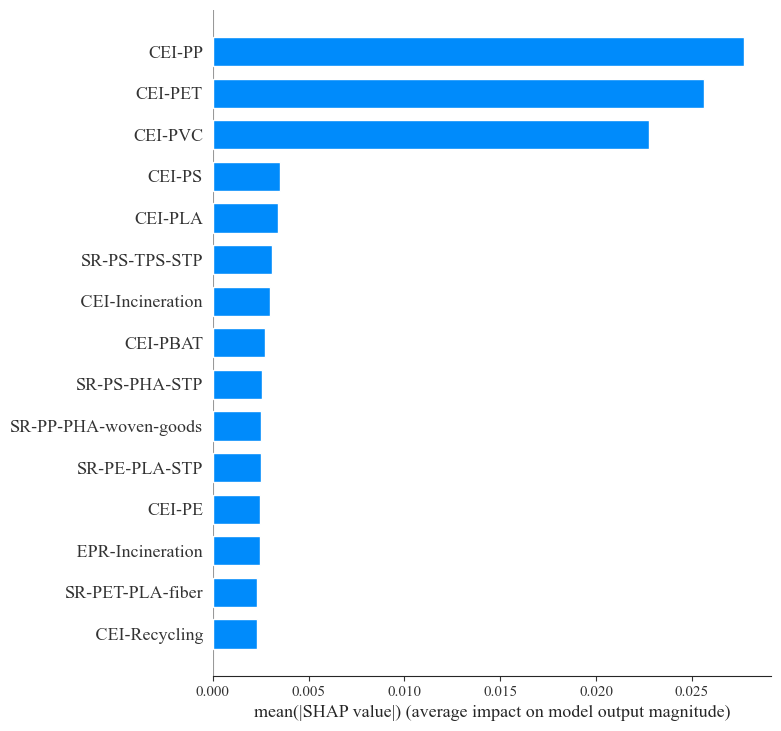

In [30]:
shap.summary_plot(shap_values, X_test,plot_type='bar',max_display=15
                  )
# max_display=10是指最多显示10个指标

In [37]:
feature_importance = pd.DataFrame()

feature_importance['feature'] = feature_names

feature_importance['importance'] = np.abs(shap_values).mean(0)

feature_importance.sort_values('importance', ascending=False)


,feature,importance
32,UCE-PP,0.027734
31,UCE-PET,0.025639
34,UCE-PVC,0.022751
33,UCE-PS,0.003502
29,UCE-PLA,0.003398
18,SR-PS-TPS-STP,0.003101
36,UCE-Incineration,0.003008
27,UCE-PBAT,0.002728
16,SR-PS-PHA-STP,0.002563
5,SR-PP-PHA-woven-goods,0.002500
